In [40]:
%reload_ext autoreload
%autoreload 2
# %matplotlib qt
%matplotlib inline

import random
import numpy as np
import torch
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import format_spines, beeswarm, errorPlot, save_figure, add_scaled_limits
from vrAnalysis.processors.placefields import get_placefield
from dimilibi import PCA, SVCA
from dimensionality_manuscript.registry import PopulationRegistry, get_subspace, SubspaceName, RegistryPaths
from dimensionality_manuscript.subspace_analysis.base import Subspace
from dimensionality_manuscript.regression_models.hyperparameters import PlaceFieldHyperparameters
from dimensionality_manuscript.simulations import sqrtm_spd
from dimensionality_manuscript import SubspaceConfig, StimSpaceConfig, StimSpaceSpectraConfig
from dimensionality_manuscript import ResultsAggregator, ResultsStore, get_data_config
from dimensionality_manuscript.scripts.status import status
from dimensionality_manuscript.subspace_analysis.stimspace import StimSpaceSubspace
from dimensionality_manuscript import average_by_mouse
plt.rcParams["font.size"] = 14

from dimensionality_manuscript.figure_scripts.figure3 import subspace_crossspace

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
registry = PopulationRegistry()
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure3"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [68]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = StimSpaceSpectraConfig()
results = ResultsAggregator(cfg, store, sessions)

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


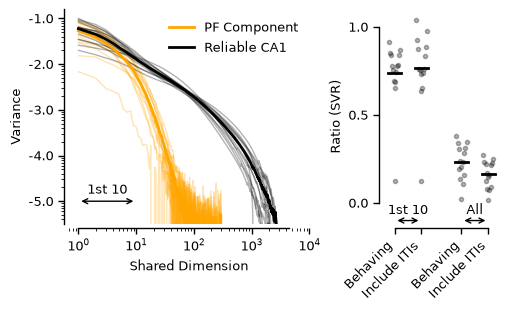

In [69]:
def xvals(x):
    return np.arange(x.shape[1]) + 1

activity_parameters_name = "default"
smooth_widths = (5.0, None)
reliability_fraction_active_thresholds = (None, None)
sel_params = {
    "activity_parameters_name": activity_parameters_name,
    "smooth_widths": smooth_widths,
    "reliability_fraction_active_thresholds": reliability_fraction_active_thresholds,
}
out = results.sel(keys=["sf_cv", "ff"], **sel_params, avg_by_mouse=True, include_iti=False)
out_iti = results.sel(keys=["sf_cv", "ff"], **sel_params, avg_by_mouse=True, include_iti=True)

full_sum = np.nansum(out["ff"], axis=1, keepdims=True)
full_sum_iti = np.nansum(out_iti["ff"], axis=1, keepdims=True)
sf_cv = out["sf_cv"] / full_sum
sf_cv_iti = out_iti["sf_cv"] / full_sum_iti
ff = out["ff"] / full_sum
ff_iti = out_iti["ff"] / full_sum_iti

full_sum_10 = np.nansum(out["ff"][:, :10], axis=1, keepdims=True)
full_sum_iti_10 = np.nansum(out_iti["ff"][:, :10], axis=1, keepdims=True)
sf_cv_10 = out["sf_cv"][:, :10] / full_sum_10
sf_cv_iti_10 = out_iti["sf_cv"][:, :10] / full_sum_iti_10

# Measure cumulative variance after normalizing
sf_cv_total = np.nansum(sf_cv, axis=1)
sf_cv_total_iti = np.nansum(sf_cv_iti, axis=1)
sf_cv_total_10 = np.nansum(sf_cv_10, axis=1)
sf_cv_total_iti_10 = np.nansum(sf_cv_iti_10, axis=1)

fontsize = 9
plt.rcParams["font.size"] = fontsize
ylim_min = -5.5
ylim_max = -0.8
yline = -5.0

ss_color = "blue"
sf_color = "orange"
ff_color = "black"
each_alpha = 0.3
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(5, 3), layout="constrained", width_ratios=[1, 0.5])

ax[0].plot(xvals(sf_cv), sf_cv.T, color=sf_color, alpha=each_alpha, linewidth=1.0)
ax[0].plot(xvals(ff), ff.T, color=ff_color, alpha=each_alpha, linewidth=1.0)
ax[0].plot(xvals(sf_cv), np.nanmean(sf_cv, axis=0), color=sf_color, label="PF Component", linewidth=2.0)
ax[0].plot(xvals(ff), np.nanmean(ff, axis=0), color=ff_color, label="Reliable CA1", linewidth=2.0)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ylim = (10 **ylim_min, 10 **ylim_max)
yticks = ax[0].get_yticks()
ytick_power = [np.log10(yt) for yt in yticks]
ax[0].set_yticks(yticks, labels=ytick_power)
ax[0].set_ylim(*ylim)
ax[0].set_xlabel("Shared Dimension")
ax[0].set_ylabel("Variance")
xlim = ax[0].get_xlim()
format_spines(
    ax[0],
    x_pos=-0.02,
    y_pos=-0.02,
    spines_visible=["left", "bottom"],
    xbounds=[1, xlim[1]],
    ybounds=[ylim[0], ylim[1]],
)
ax[0].legend(loc="upper right", fontsize=fontsize, frameon=False)
xticks = ax[0].get_xticks()
xticks = xticks[xticks >= 1]
ax[0].set_xticks(xticks)
ax[0].annotate(
    "",
    xy=(10, 10**yline),
    xytext=(1, 10**yline),
    arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.0),
    annotation_clip=False,
)
ax[0].text(np.sqrt(10), 10**(yline+0.1), "1st 10", fontsize=fontsize, ha="center", va="bottom")

# Also plot ratio of cumulative variance
xticks = [0, 1, 2.5, 3.5]
xticklabels = ["Behaving", "Include ITIs"]

beewidth = 0.2
alpha = 0.3
line_extent = np.array([-0.25, 0.25])
np1 = np.array([1, 1])
linewidth = 2.0
ax[1].plot(xticks[0] + beewidth * beeswarm(sf_cv_total_10), sf_cv_total_10, color="black", linestyle="none", linewidth=0.5, marker="o", markersize=3, alpha=alpha)
ax[1].plot(xticks[1] + beewidth * beeswarm(sf_cv_total_iti_10), sf_cv_total_iti_10, color="black", linestyle="none", linewidth=0.5, marker="o", markersize=3, alpha=alpha)
ax[1].plot(xticks[2] + beewidth * beeswarm(sf_cv_total), sf_cv_total, color="black", linestyle="none", linewidth=0.5, marker="o", markersize=3, alpha=alpha)
ax[1].plot(xticks[3] + beewidth * beeswarm(sf_cv_total_iti), sf_cv_total_iti, color="black", linestyle="none", linewidth=0.5, marker="o", markersize=3, alpha=alpha)
ax[1].plot(xticks[0] + line_extent, np1*np.nanmean(sf_cv_total_10), color="black", linewidth=linewidth)
ax[1].plot(xticks[1] + line_extent, np1*np.nanmean(sf_cv_total_iti_10), color="black", linewidth=linewidth)
ax[1].plot(xticks[2] + line_extent, np1*np.nanmean(sf_cv_total), color="black", linewidth=linewidth)
ax[1].plot(xticks[3] + line_extent, np1*np.nanmean(sf_cv_total_iti), color="black", linewidth=linewidth)
ax[1].set_ylim(-0.12, 1.10)
ax[1].set_xlim(-0.5, max(xticks) + 0.5)
ax[1].set_ylabel("Ratio (SVR)")
yline = -0.10
ax[1].annotate(
    "",
    xy=(xticks[0], yline),
    xytext=(xticks[1], yline),
    arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.0),
    annotation_clip=False,
)
ax[1].text(np.mean(xticks[0:2]), yline + 0.02, "1st 10", fontsize=fontsize, ha="center", va="bottom")
ax[1].annotate(
    "",
    xy=(xticks[2], yline),
    xytext=(xticks[3], yline),
    arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.0),
    annotation_clip=False,
)
ax[1].text(np.mean(xticks[2:4]), yline + 0.02, "All", fontsize=fontsize, ha="center", va="bottom")
format_spines(
    ax[1],
    x_pos=-0.02,
    y_pos=-0.02,
    spines_visible=["left", "bottom"],
    xbounds=[0, max(xticks)],
    ybounds=[0, 1],
    yticks=[0, 0.5, 1.0],
)
ax[1].set_xticks(xticks, labels=xticklabels+xticklabels, rotation=45, ha="right")
plt.show()

save = True
if save:
    save_figure(fig, figure_path / "subspace_curves_ratios")

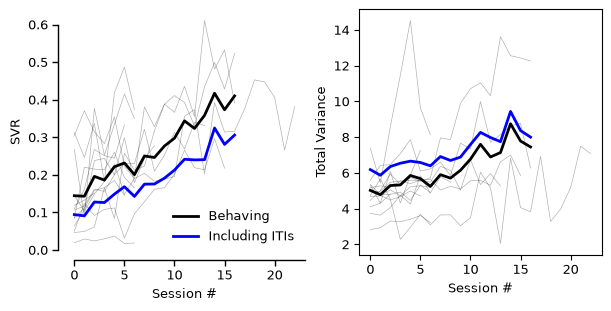

In [70]:
activity_parameters_name = "default"
smooth_widths = (5.0, None)
reliability_fraction_active_thresholds = (None, None)
sel_params = {
    "activity_parameters_name": activity_parameters_name,
    "smooth_widths": smooth_widths,
    "reliability_fraction_active_thresholds": reliability_fraction_active_thresholds,
}
out = results.sel(keys=["sf_cv", "ff"], **sel_params, avg_by_mouse=False, include_iti=False)
out_iti = results.sel(keys=["sf_cv", "ff"], **sel_params, avg_by_mouse=False, include_iti=True)

full_sum = np.nansum(out["ff"], axis=1)
full_sum_iti = np.nansum(out_iti["ff"], axis=1)
sf_cv = out["sf_cv"] / full_sum[:, None]
sf_cv_iti = out_iti["sf_cv"] / full_sum_iti[:, None]
ff = out["ff"] / full_sum[:, None]
ff_iti = out_iti["ff"] / full_sum_iti[:, None]

# Measure cumulative variance after normalizing
sf_cv_total = np.nansum(sf_cv, axis=1)
sf_cv_total_iti = np.nansum(sf_cv_iti, axis=1)


normalize_to_mouse_first = False
svr = {}
svr_iti = {}
total = {}
total_iti = {}
num_envs = {}
unique_mice = results.unique_mice
bad_envs = np.array([-1 in session.environments for session in results.sessions], dtype=bool)
for mouse in unique_mice:
    idx_mouse = results.mouse_names == mouse
    idx_to_mouse = np.where(idx_mouse & ~bad_envs)[0]

    dates = np.array([results.sessions[idx].date for idx in idx_to_mouse])
    _idx_sorted = np.argsort(dates)
    idx_to_mouse = idx_to_mouse[_idx_sorted]
    num_envs[mouse] = np.array([len(results.sessions[idx].environments) for idx in idx_to_mouse])
    svr[mouse] = sf_cv_total[idx_to_mouse]
    svr_iti[mouse] = sf_cv_total_iti[idx_to_mouse]
    total[mouse] = full_sum[idx_to_mouse]
    total_iti[mouse] = full_sum_iti[idx_to_mouse]

    if normalize_to_mouse_first:
        svr[mouse] = svr[mouse] / svr[mouse][0]
        total[mouse] = total[mouse] / total[mouse][0]
        svr_iti[mouse] = svr_iti[mouse] / svr_iti[mouse][0]
        total_iti[mouse] = total_iti[mouse] / total_iti[mouse][0]


max_length = max([len(svr[mouse]) for mouse in unique_mice] + [len(svr_iti[mouse]) for mouse in unique_mice])
svr_pad_stack = np.full((len(unique_mice), max_length), np.nan)
total_pad_stack = np.full((len(unique_mice), max_length), np.nan)
svr_pad_stack_iti = np.full((len(unique_mice), max_length), np.nan)
total_pad_stack_iti = np.full((len(unique_mice), max_length), np.nan)
for imouse, mouse in enumerate(unique_mice):
    svr_pad_stack[imouse, :len(svr[mouse])] = svr[mouse]
    total_pad_stack[imouse, :len(total[mouse])] = total[mouse]
    svr_pad_stack_iti[imouse, :len(svr_iti[mouse])] = svr_iti[mouse]
    total_pad_stack_iti[imouse, :len(total_iti[mouse])] = total_iti[mouse]

max_length_greater1 = np.where(np.sum(~np.isnan(svr_pad_stack), axis=0) > 1)[0][-1] + 1
max_length_greater1_iti = np.where(np.sum(~np.isnan(svr_pad_stack_iti), axis=0) > 1)[0][-1] + 1

fontsize = 9
plt.rcParams["font.size"] = fontsize


mouse_cmap = plt.colormaps["viridis"](np.linspace(0, 1, len(unique_mice)))
env_cmap = ["black", "brown", "tomato"]
markersize = 2
line_alpha = 0.3
fig, ax = plt.subplots(1, 2, figsize=(6, 3), layout="constrained")
for imouse, mouse in enumerate(unique_mice):
    num_points = len(svr[mouse])
    unique_numenvs = np.unique(num_envs[mouse])
    mouse_color = "black" # mouse_cmap[imouse]
    ax[0].plot(np.arange(num_points), svr[mouse], color=(mouse_color, line_alpha), linewidth=0.5)
    ax[1].plot(np.arange(num_points), total[mouse], color=(mouse_color, line_alpha), linewidth=0.5)

ax[0].plot(np.arange(max_length_greater1), np.nanmean(svr_pad_stack[:, :max_length_greater1], axis=0), color="k", linewidth=2.0, label="Behaving")
ax[0].plot(np.arange(max_length_greater1_iti), np.nanmean(svr_pad_stack_iti[:, :max_length_greater1_iti], axis=0), color="blue", linewidth=2.0, label="Including ITIs")
ax[1].plot(np.arange(max_length_greater1), np.nanmean(total_pad_stack[:, :max_length_greater1], axis=0), color="k", linewidth=2.0)
ax[1].plot(np.arange(max_length_greater1_iti), np.nanmean(total_pad_stack_iti[:, :max_length_greater1_iti], axis=0), color="blue", linewidth=2.0)
ax[0].set_xlabel("Session #")
ax[1].set_xlabel("Session #")
ax[0].set_ylabel("SVR")
ax[1].set_ylabel("Total Variance")

max_yval = max(np.nanmax(svr_pad_stack), np.nanmax(svr_pad_stack_iti))
ybounds = [0, np.round(max_yval, 1)]
ylims = [0, max_yval * 1.05]

ax[0].legend(loc="lower right", fontsize=fontsize, frameon=False)
format_spines(
    ax[0],
    x_pos=-0.02,
    y_pos=-0.02,
    spines_visible=["left", "bottom"],
    xbounds=[0, svr_pad_stack.shape[1]],
    ybounds=ybounds,
)


plt.show()

save = False
if save:
    save_figure(fig, figure_path / "svr_over_familiarity")

In [71]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
results_subspace = ResultsAggregator(SubspaceConfig, store, sessions)

In [72]:
crossspace_viewer = subspace_crossspace(results_subspace, idx_cross=2, return_syd_viewer=True)
crossspace_viewer.show()

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


In [ ]:
save=False
if save:
    save_figure(crossspace_viewer.figure, figure_path / "subspace_crossspace")